## Setup

In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image

FIGURES = Path("../figures")
PLOTS = Path("../plots")  # per-step frames for the GIFs (git-ignored)
FIGURES.mkdir(exist_ok=True)
PLOTS.mkdir(exist_ok=True)

## The simple harmonic oscillator

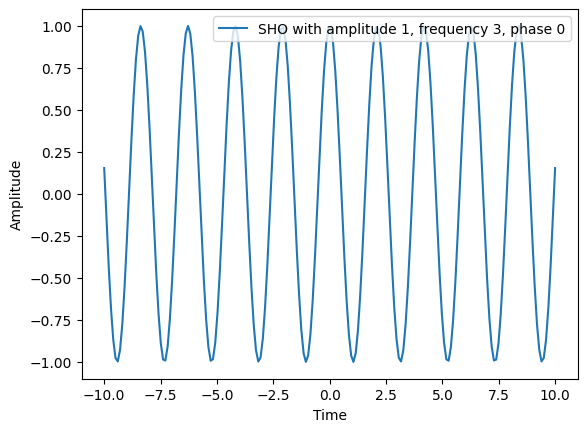

In [3]:
example_amplitude = 1
example_phase = 0
example_frequency = 3
example_times = np.linspace(-10, 10, 200)

def sho(amplitude, frequency, phase, time):
    return amplitude * np.cos(frequency * time + phase)

shos = sho(example_amplitude, example_frequency, example_phase, example_times)
plt.plot(example_times, shos)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend([f"SHO with amplitude {example_amplitude}, frequency {example_frequency}, phase {example_phase}"], loc="upper right")
plt.show()

## Fitting the data with a standard neural network

In [4]:
amplitude = 1
frequency = 30
phase = 0

time = torch.linspace(0, 1, 200).view(-1, 1)
sho_analytic_solution = sho(amplitude, frequency, phase, time).view(-1, 1)

# 10 training points, all in the first quarter of the domain
time_samples = time[0:50:5]
sho_samples = sho_analytic_solution[0:50:5]

### Neural Network Architecture Design

Design a neural network to approximate the SHO solution. Here are our key design choices:

Architecture: Fully Connected (Feed-Forward) Network
- Input layer: 1 neuron (time t)
- Hidden layers: Multiple layers with many neurons
- Output layer: 1 neuron (position x)

Why this structure?
- We're learning a function x(t): one input -> one output
- Hidden layers allow the network to learn complex, non-linear mappings
- More layers and neurons = more capacity to represent oscillatory behavior

Activation Function: Tanh
We use tanh for several important reasons:
- Smoothness: tanh is infinitely differentiable, which is crucial because we'll compute (dx/dt) and (d^2x/dt^2) through the network
- Bounded output: tanh outputs values in [-1, 1], similar to our oscillator's bounded motion
- Zero-centered: Unlike ReLU, tanh can naturally represent both positive and negative values

Note: ReLU would be problematic here because its second derivative is zero everywhere (except at the kink), making it impossible to satisfy our physics equation!

In [7]:
class shoNN(torch.nn.Module):
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh

        self.input_layer = nn.Sequential(
            nn.Linear(N_INPUT, N_HIDDEN),
            activation()
        )

        hidden = []
        for _ in range(N_LAYERS - 1):
            hidden.append(nn.Linear(N_HIDDEN, N_HIDDEN))
            hidden.append(activation())
        self.hidden_layers = nn.Sequential(*hidden)

        self.output_layer = nn.Linear(N_HIDDEN, N_OUTPUT)
    
    def forward(self, x):
        x = self.input_layer(x)
        x = self.hidden_layers(x)
        x = self.output_layer(x)
        return x

In [8]:
# Sanity check: with every weight set to 0.5 the output is known exactly
test_model = shoNN(1, 1, 20, 2)
with torch.no_grad():
    for param in test_model.parameters():
        param.fill_(0.5)

assert isinstance(test_model, torch.nn.Module)
input_data = torch.tensor([[0.0], [0.1], [0.2], [0.3]])
output_data = test_model(input_data)
assert output_data.shape == (4, 1)
expected_output = torch.tensor([[10.499288], [10.499669], [10.499841], [10.499922]])
assert torch.allclose(output_data, expected_output, atol=1e-6)

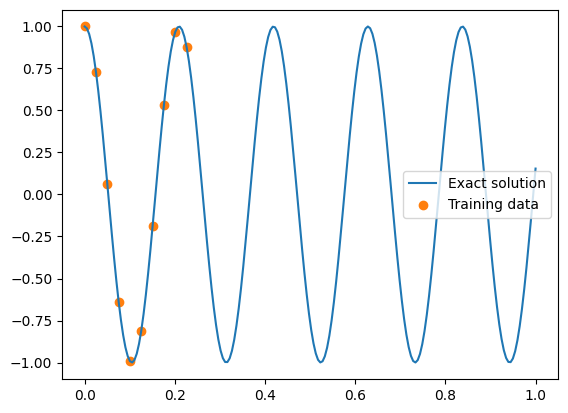

In [9]:
plt.figure()
plt.plot(time, sho_analytic_solution, label="Exact solution"),
plt.scatter(time_samples, sho_samples, color="tab:orange", label="Training data")
plt.legend()
plt.show()

In [10]:
def plot_result(x, y, x_data, y_data, yh, xp=None, step=None):
    """Plot the exact solution, NN prediction, training data and (optionally) collocation points."""
    plt.figure(figsize=(8, 4))
    plt.plot(x, y, color="grey", linewidth=2, alpha=0.8, label="Exact solution")
    plt.plot(x, yh, color="tab:blue", linewidth=4, alpha=0.8, label="Neural network prediction")
    plt.scatter(x_data, y_data, s=60, color="tab:orange", alpha=0.4, label="Training data")
    if xp is not None:
        plt.scatter(xp, np.zeros_like(xp), s=60, color="tab:green", alpha=0.4, label="Physics loss training locations")
    legend = plt.legend(loc=(1.01, 0.34), frameon=False, fontsize="large")
    plt.setp(legend.get_texts(), color="k")
    plt.xlim(-0.05, 1.05)
    plt.ylim(-1.1, 1.1)
    if step is not None:
        plt.text(1.065, 0.7, f"Training step: {step}", fontsize="xx-large", color="k")
    plt.axis("off")

def save_gif_PIL(outfile, files, fps=5, loop=0):
    images = [Image.open(fn) for fn in files]
    images[0].save(outfile, save_all=True, append_images=images[1:], optimize=False, duration=1000 / fps, loop=loop)

In [11]:
def simple_mse_loss(predicted: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """Data loss only: mean squared error against the training points."""
    return torch.mean((predicted - target) ** 2)

assert simple_mse_loss(torch.tensor([[1.0], [2.0], [3.0]]), torch.tensor([[1.0], [2.0], [3.0]])).item() == 0.0
assert torch.allclose(simple_mse_loss(torch.tensor([[1.0], [2.0], [3.0]]), torch.tensor([[1.1], [2.1], [3.1]])).detach(), torch.tensor(0.01))

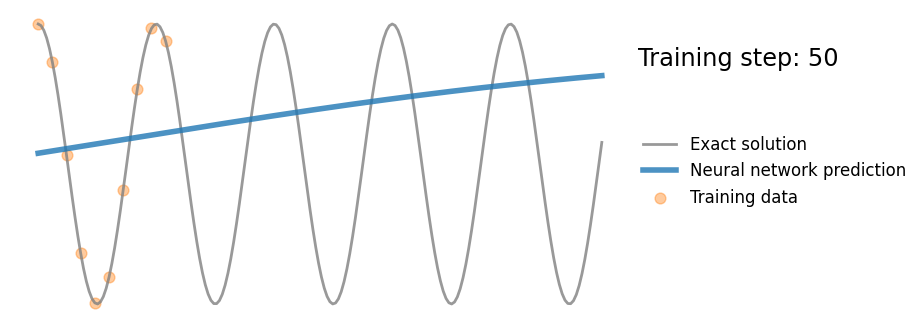

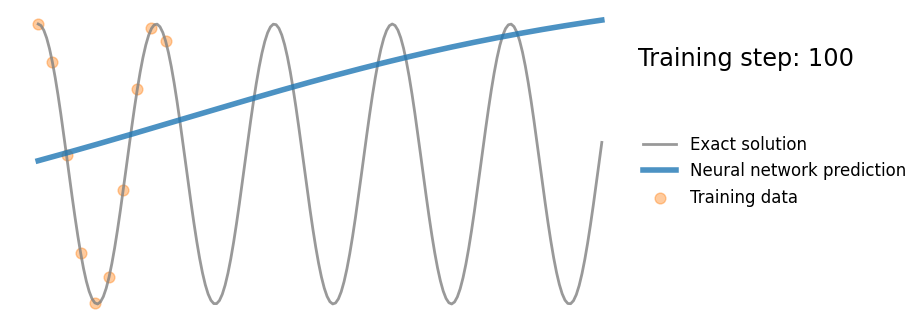

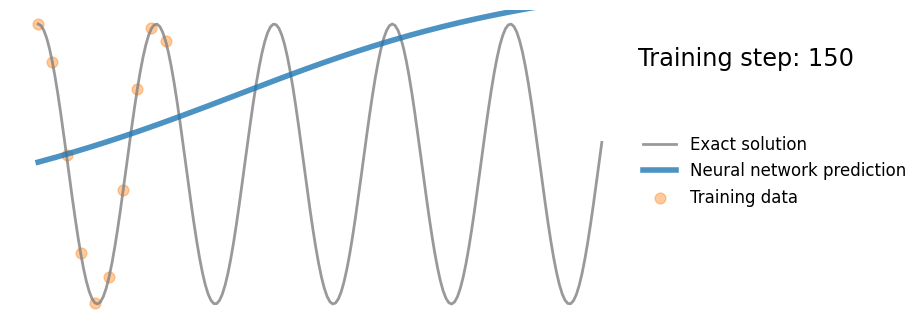

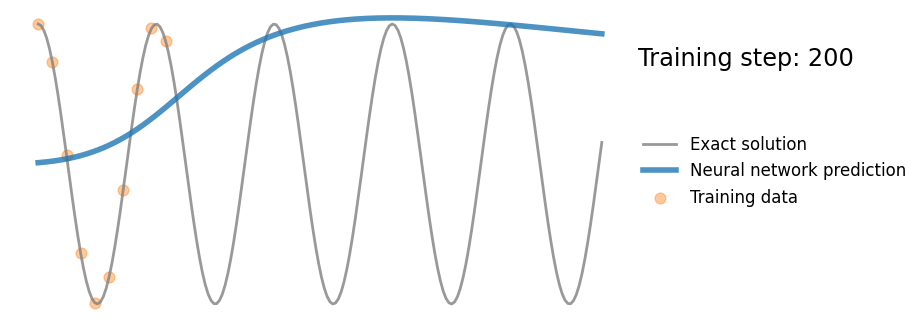

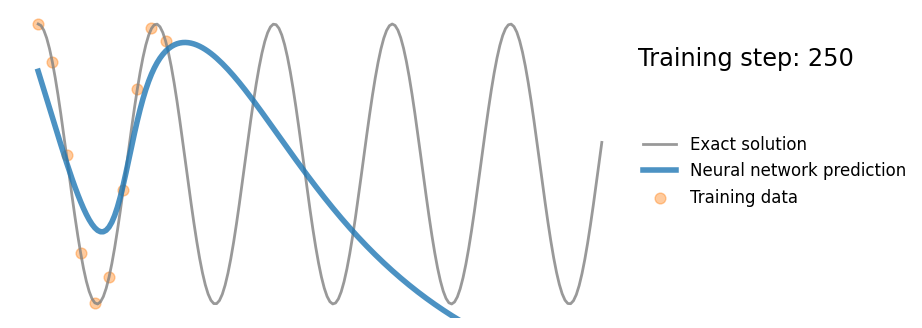

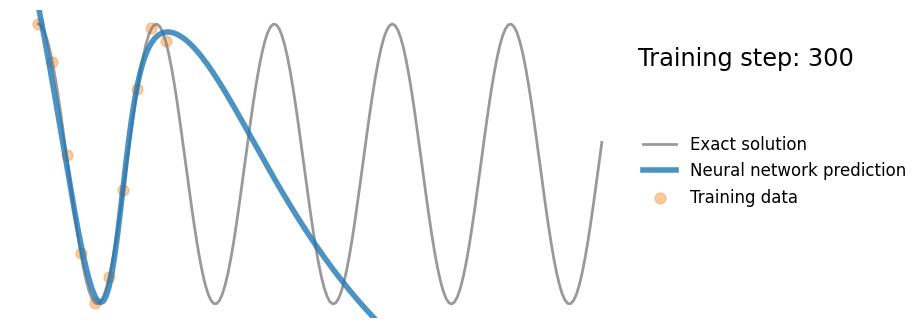

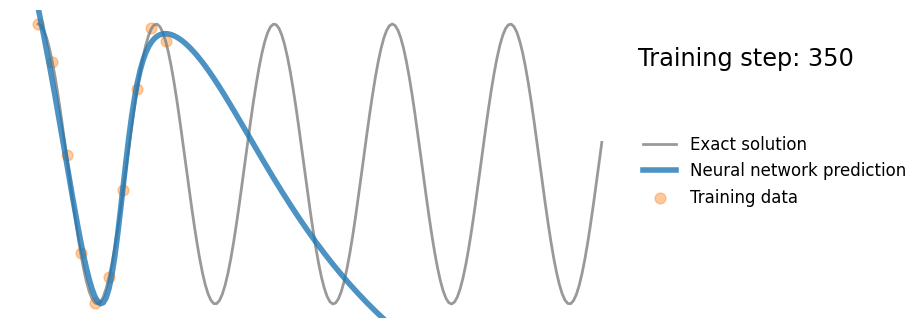

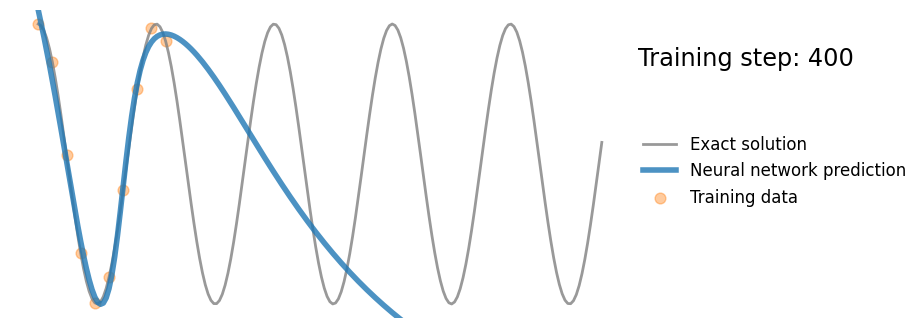

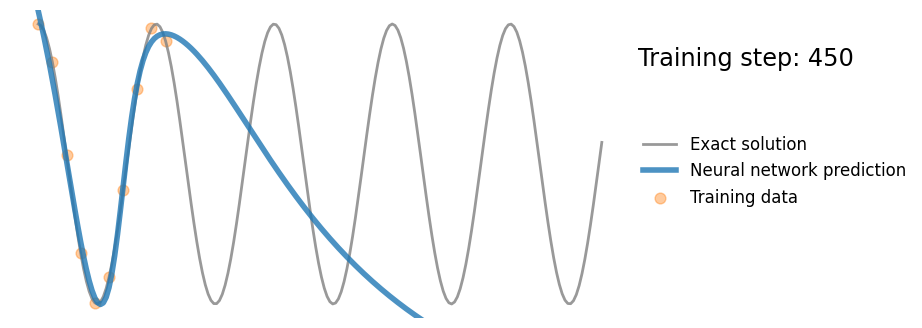

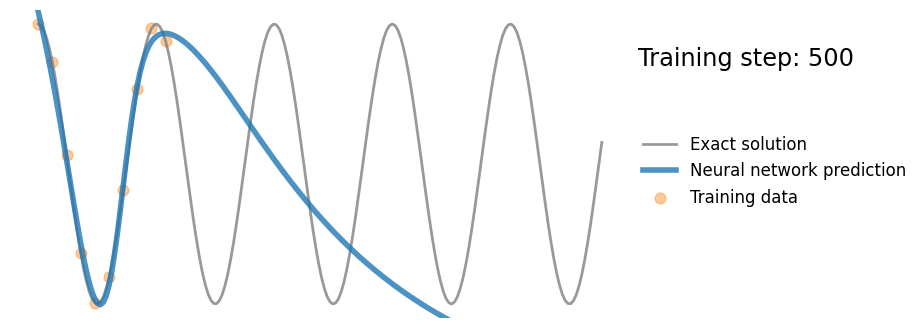

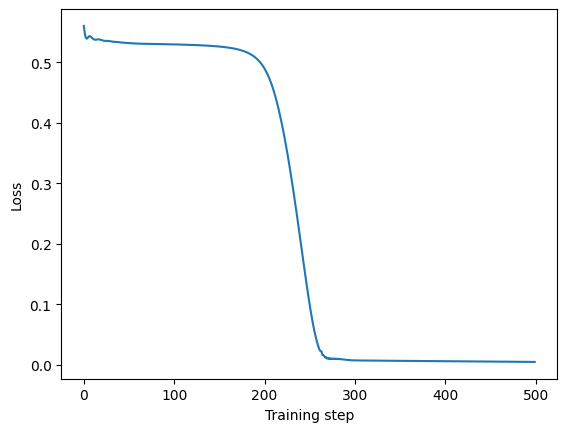

In [26]:
# Baseline: data loss only, no physics
torch.manual_seed(123)
model = shoNN(1, 1, 32, 3)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
files = []
losses = []
for i in range(500):
    optimizer.zero_grad()
    sho_predicted = model(time_samples)
    loss = simple_mse_loss(predicted=sho_predicted, target=sho_samples)
    losses.append(loss.item())
    loss.backward()
    optimizer.step()

    if (i + 1) % 10 == 0:
        sho_predicted_plot = model(time).detach()
        plot_result(time, sho_analytic_solution, time_samples, sho_samples, sho_predicted_plot, step=i + 1)
        file = PLOTS / f"nn_{i + 1:08d}.png"
        plt.savefig(file, bbox_inches="tight", pad_inches=0.1, dpi=100, facecolor="white")
        files.append(file)
        if (i + 1) % 50 == 0:
            plt.show()
        else:
            plt.close()

plt.plot(losses)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.show()

save_gif_PIL(FIGURES / "nn_nosholoss.gif", files, fps=20, loop=0)

## Physics-informed neural network

In [27]:
def compute_model_and_derivatives(model, time_vector):
    """Return x(t), dx/dt and d2x/dt2, all computed through the network with autograd."""
    time_vector.requires_grad = True
    model_outputs = model(time_vector)
    first_derivative = torch.autograd.grad(
        outputs=model_outputs,
        inputs=time_vector,
        grad_outputs=torch.ones_like(model_outputs),
        create_graph=True,
    )[0]
    second_derivative = torch.autograd.grad(
        outputs=first_derivative,
        inputs=time_vector,
        grad_outputs=torch.ones_like(first_derivative),
        create_graph=True,
    )[0]
    return model_outputs, first_derivative, second_derivative

In [28]:
torch.manual_seed(123)
model = shoNN(1, 1, 32, 3)
time_vector = torch.linspace(0, 1, steps=10).view(-1, 1)
model_outputs, first_derivative, second_derivative = compute_model_and_derivatives(model, time_vector)

for tensor in (model_outputs, first_derivative, second_derivative):
    assert isinstance(tensor, torch.Tensor) and tensor.shape == time_vector.shape

assert torch.allclose(model_outputs, model(time_vector))
assert torch.allclose(first_derivative, torch.autograd.grad(
    outputs=model_outputs, inputs=time_vector, grad_outputs=torch.ones_like(model_outputs), create_graph=True
)[0])
assert torch.allclose(second_derivative, torch.autograd.grad(
    outputs=first_derivative, inputs=time_vector, grad_outputs=torch.ones_like(first_derivative), create_graph=True
)[0])

In [30]:
def physics_loss(amplitude, first_derivative, second_derivative, frequency):
    """Mean squared residual of x'' + omega^2 x = 0 (first_derivative unused; kept for a uniform signature)."""
    return torch.mean((second_derivative + (frequency ** 2) * amplitude) ** 2)

In [ ]:
zero = torch.tensor([0.0])
assert physics_loss(zero, zero, zero, zero) == torch.tensor([0.0])

one = torch.tensor([1.0])
assert physics_loss(one, one, one, one) == torch.tensor([4.0])

In [33]:
def compute_initial_condition_loss(predicted_amplitude, predicted_first_derivative, expected_amplitude=1, expected_first_derivative=0):
    """Squared error of x(0) and x'(0) against their target values."""
    return (predicted_amplitude - expected_amplitude) ** 2 + (predicted_first_derivative - expected_first_derivative) ** 2

In [34]:
# Test when predicted values match the expected values
assert compute_initial_condition_loss(1, 0) == 0, "Test failed: Expected loss is 0 when predicted values match the expected values"

# Test when predicted values do not match the expected values
assert compute_initial_condition_loss(2, 1) == 2, "Test failed: Expected loss is 2 when predicted values do not match the expected values"

# Test when expected values are different from the default values
assert compute_initial_condition_loss(2, 1, 2, 1) == 0, "Test failed: Expected loss is 0 when predicted values match the non-default expected values"

# Test with negative values
assert compute_initial_condition_loss(-1, -1) == 5, "Test failed: Expected loss is 5 when predicted values are negative"

# Test with floating point values
assert compute_initial_condition_loss(1.5, 0.5) == 0.5, "Test failed: Expected loss is 0.5 when predicted values are floating point numbers"

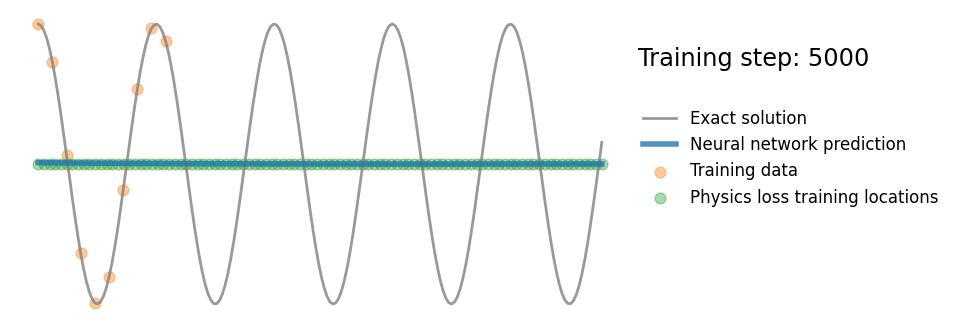

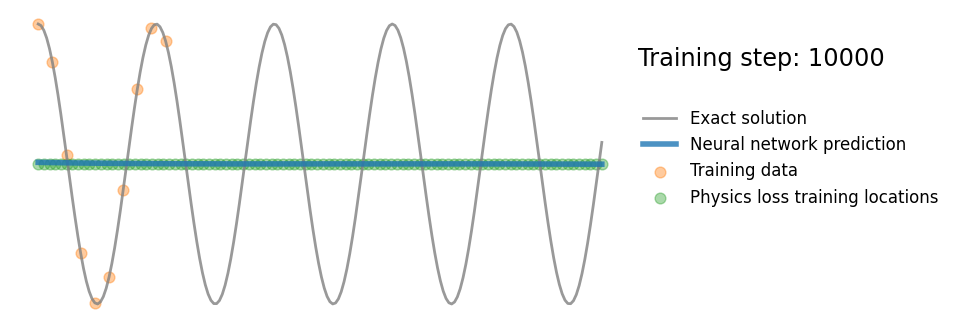

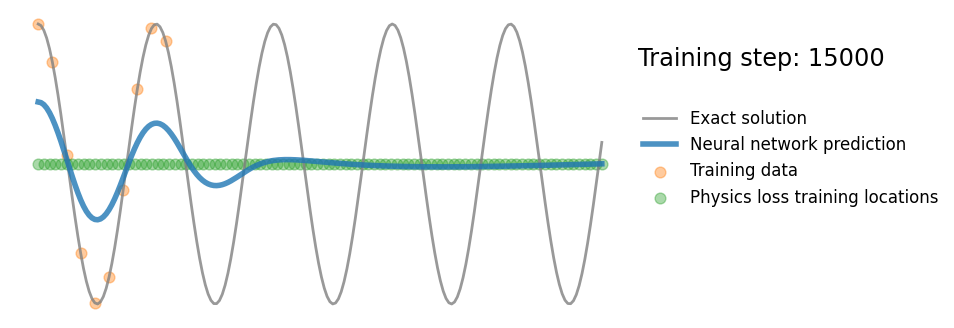

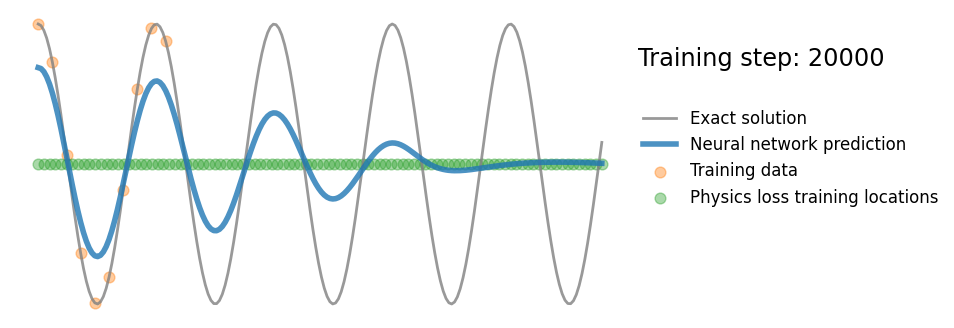

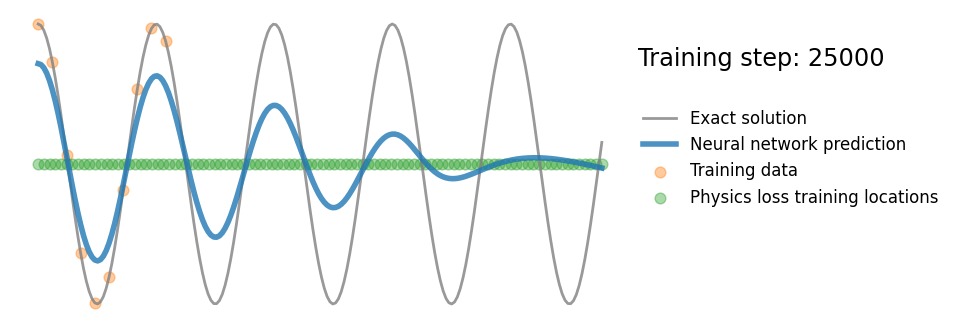

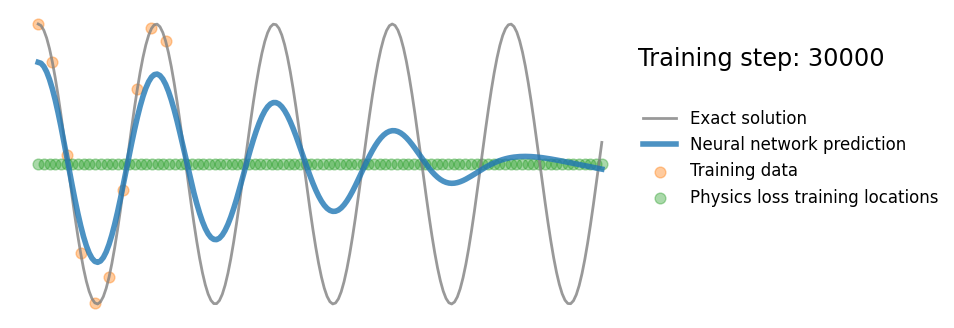

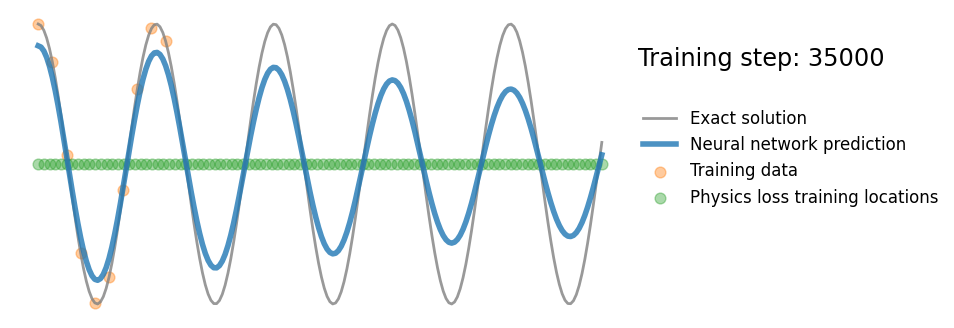

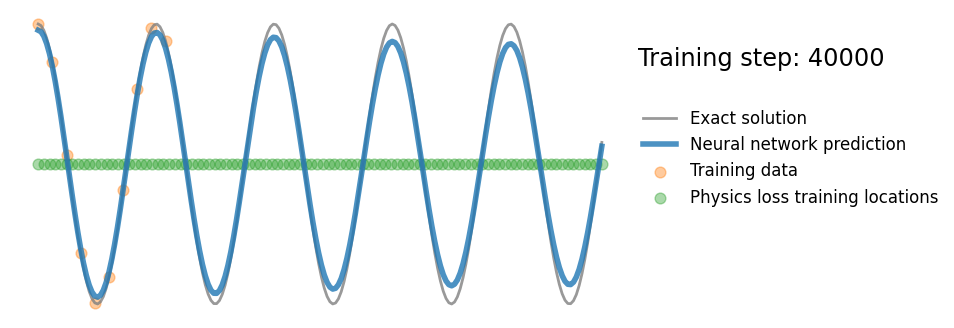

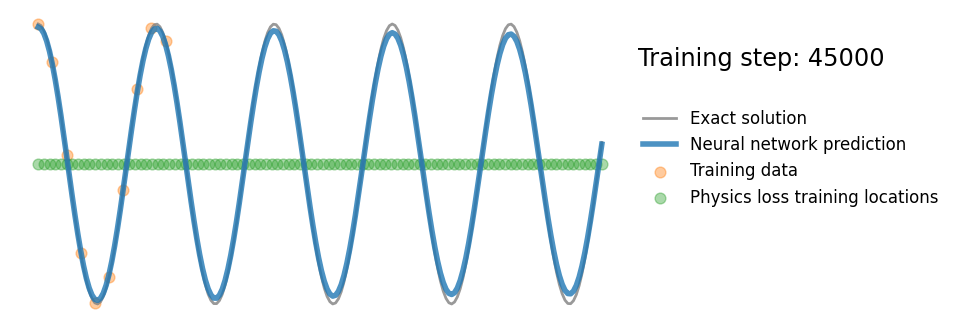

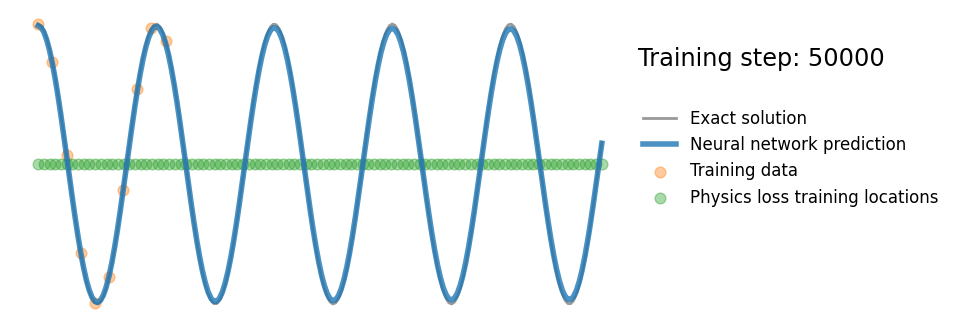

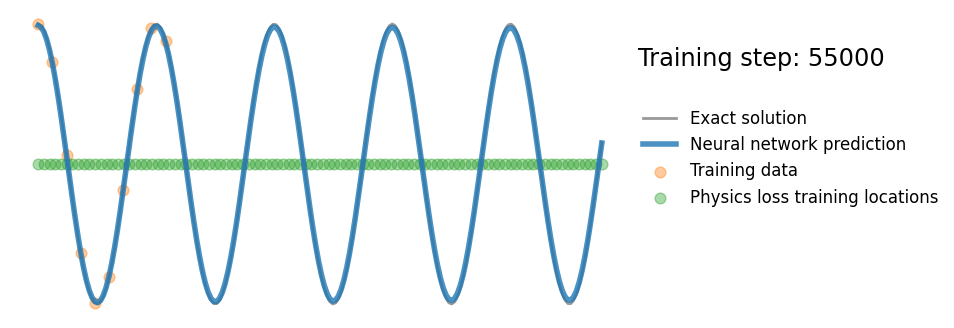

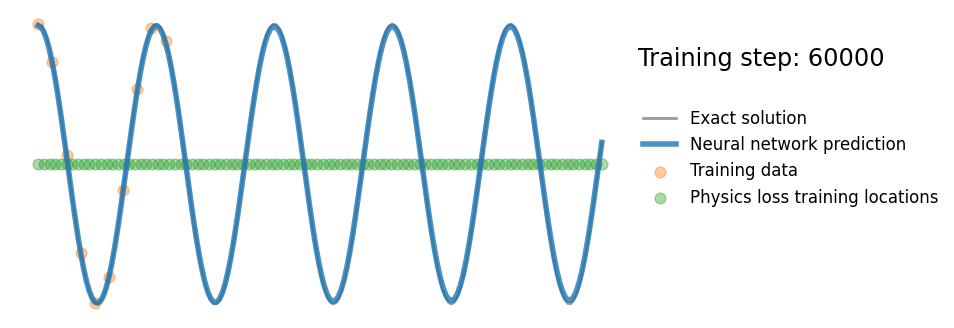

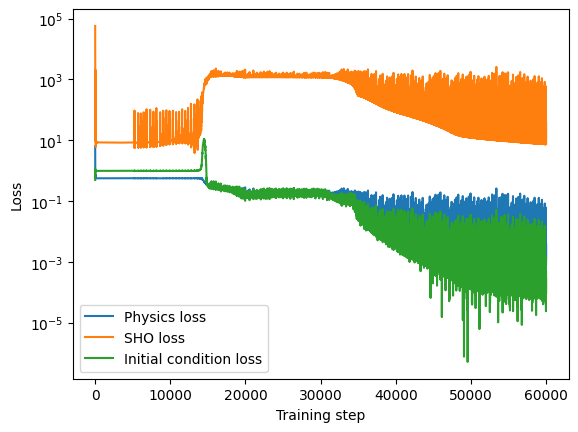

In [38]:
# Collocation points where the ODE residual is enforced
time_physics = torch.linspace(0, 1, 100).view(-1, 1).requires_grad_(True)
# t = 0, for the initial conditions x(0) = 1, x'(0) = 0
initial_time = torch.tensor(0.0).view(-1, 1).requires_grad_(True)

torch.manual_seed(1)
model = shoNN(1, 1, 32, 3)
files = []
sho_loss_weight = 1e-4
initial_condition_loss_weight = 1e-4
frequency = 30

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

losses_physics = []
losses_sho = []
losses_initial_condition = []

for i in range(60000):
    optimizer.zero_grad()
    sho_predicted = model(time_samples)
    loss1 = torch.mean((sho_predicted - sho_samples) ** 2)

    sho_predicted_physics, dtsho_predicted_physics, d2tsho_predicted_physics = compute_model_and_derivatives(model, time_physics)
    sho_loss = physics_loss(sho_predicted_physics, dtsho_predicted_physics, d2tsho_predicted_physics, frequency)

    initial_sho_x, initial_sho_dt, initial_sho_d2t = compute_model_and_derivatives(model, initial_time)
    initial_condition_loss = compute_initial_condition_loss(initial_sho_x, initial_sho_dt)

    loss = loss1 + sho_loss_weight * sho_loss + initial_condition_loss_weight * initial_condition_loss
    loss.backward()
    optimizer.step()
    losses_sho.append(sho_loss.item())
    losses_initial_condition.append(initial_condition_loss.item())
    losses_physics.append(loss.item())

    if (i + 1) % 200 == 0:
        sho_predicted = model(time).detach()
        time_p = time_physics.detach()
        plot_result(time, sho_analytic_solution, time_samples, sho_samples, sho_predicted, time_p, step=i + 1)
        file = PLOTS / f"nn_physics_{i + 1:08d}.png"
        plt.savefig(file, bbox_inches="tight", pad_inches=0.1, dpi=100, facecolor="white")
        files.append(file)
        if (i + 1) % 5000 == 0:
            plt.show()
        else:
            plt.close("all")

plt.plot(losses_physics, label="Total loss")
plt.plot(losses_sho, label="Physics (ODE residual) loss")
plt.plot(losses_initial_condition, label="Initial condition loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.show()

save_gif_PIL(FIGURES / "physics_nn.gif", files, fps=20, loop=0)